# EDA 02 — Tỷ lệ Required / Preferred per Skill

**Mục tiêu**: Xác định skill nào hầu như luôn `required_skill` (signal mạnh hơn cho salary prediction) vs skill thường chỉ là `preferred_skill` (signal yếu hơn).

**Input**: `data/processed/skills.parquet`  
**Key columns**: `final_canonical`, `label`, `category`, `job_id`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

DATA_DIR = Path('../data/processed')

## 1. Load & tổng quan

In [2]:
df = pd.read_parquet(DATA_DIR / 'skills.parquet')

# Giữ chỉ 2 label hợp lệ
df = df[df['label'].isin(['required_skill', 'preferred_skill'])].copy()

# Dùng final_canonical nếu có, fallback về skill_name lowercase
df['canonical'] = df['final_canonical'].fillna(df['skill_name'].str.lower().str.strip())

print(f"Total skill mentions : {len(df):,}")
print(f"Unique canonical     : {df['canonical'].nunique():,}")
print(f"Unique jobs          : {df['job_id'].nunique():,}")
print()
print(df['label'].value_counts().to_string())

Total skill mentions : 56,335
Unique canonical     : 2,762
Unique jobs          : 3,168

label
required_skill     43978
preferred_skill    12357


## 2. Tính required_ratio per canonical skill

In [3]:
skill_stats = (
    df.groupby('canonical')
    .agg(
        total       = ('label', 'count'),
        n_required  = ('label', lambda x: (x == 'required_skill').sum()),
        n_preferred = ('label', lambda x: (x == 'preferred_skill').sum()),
        n_jobs      = ('job_id', 'nunique'),
        category    = ('category', lambda x: x.mode().iloc[0] if len(x) > 0 else 'Unknown'),
    )
    .reset_index()
)

skill_stats['required_ratio'] = skill_stats['n_required'] / skill_stats['total']

# Chỉ giữ skills xuất hiện đủ nhiều để ratio có nghĩa
MIN_MENTIONS = 10
skill_filtered = skill_stats[skill_stats['total'] >= MIN_MENTIONS].copy()

print(f"Skills với >= {MIN_MENTIONS} mentions: {len(skill_filtered):,} / {len(skill_stats):,}")
skill_filtered.sort_values('required_ratio', ascending=False).head(10)

Skills với >= 10 mentions: 820 / 2,762


,canonical,total,n_required,n_preferred,n_jobs,category,required_ratio
2758,đọc và nghiên cứu tài liệu bằng tiếng anh,10,10,0,10,Soft Skill,1.0
2659,windows os,13,13,0,13,Tool & Platform,1.0
2627,web applications development,12,12,0,12,Domain Knowledge,1.0
38,ad,11,11,0,11,Infrastructure & DevOps,1.0
2630,web design,10,10,0,10,Design & UX,1.0
93,ai solutions,23,23,0,23,Soft Skill,1.0
2623,web api,16,16,0,16,Engineering Concepts & Methodologies,1.0
2586,vlan,28,28,0,28,Infrastructure & DevOps,1.0
2614,wan,17,17,0,17,Infrastructure & DevOps,1.0
2357,test report,19,19,0,19,Testing & QA,1.0


## 3. Phân phối required_ratio (histogram)

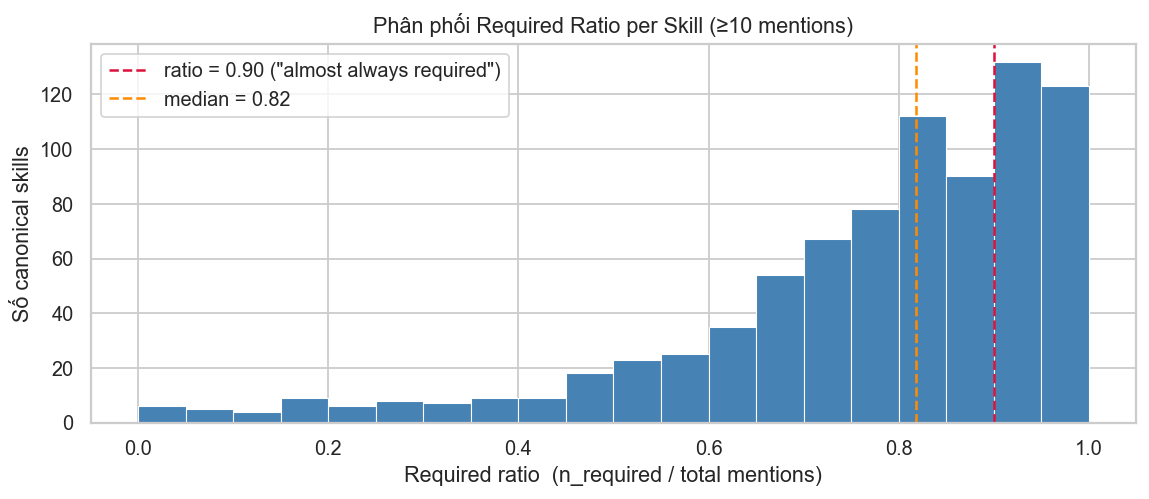

Skills có required_ratio ≥ 0.90 : 31.1% (255 skills)


In [4]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(skill_filtered['required_ratio'], bins=20, color='steelblue', edgecolor='white', linewidth=0.6)
ax.axvline(0.9, color='crimson', linestyle='--', linewidth=1.4, label='ratio = 0.90 ("almost always required")')
ax.axvline(skill_filtered['required_ratio'].median(), color='darkorange', linestyle='--',
           linewidth=1.4, label=f'median = {skill_filtered["required_ratio"].median():.2f}')

ax.set_xlabel('Required ratio  (n_required / total mentions)')
ax.set_ylabel('Số canonical skills')
ax.set_title('Phân phối Required Ratio per Skill (≥10 mentions)')
ax.legend()
plt.tight_layout()
plt.show()

pct_high = (skill_filtered['required_ratio'] >= 0.9).mean() * 100
print(f"Skills có required_ratio ≥ 0.90 : {pct_high:.1f}% ({(skill_filtered['required_ratio'] >= 0.9).sum()} skills)")

## 4. Top skills luôn required (ratio ≥ 0.90)

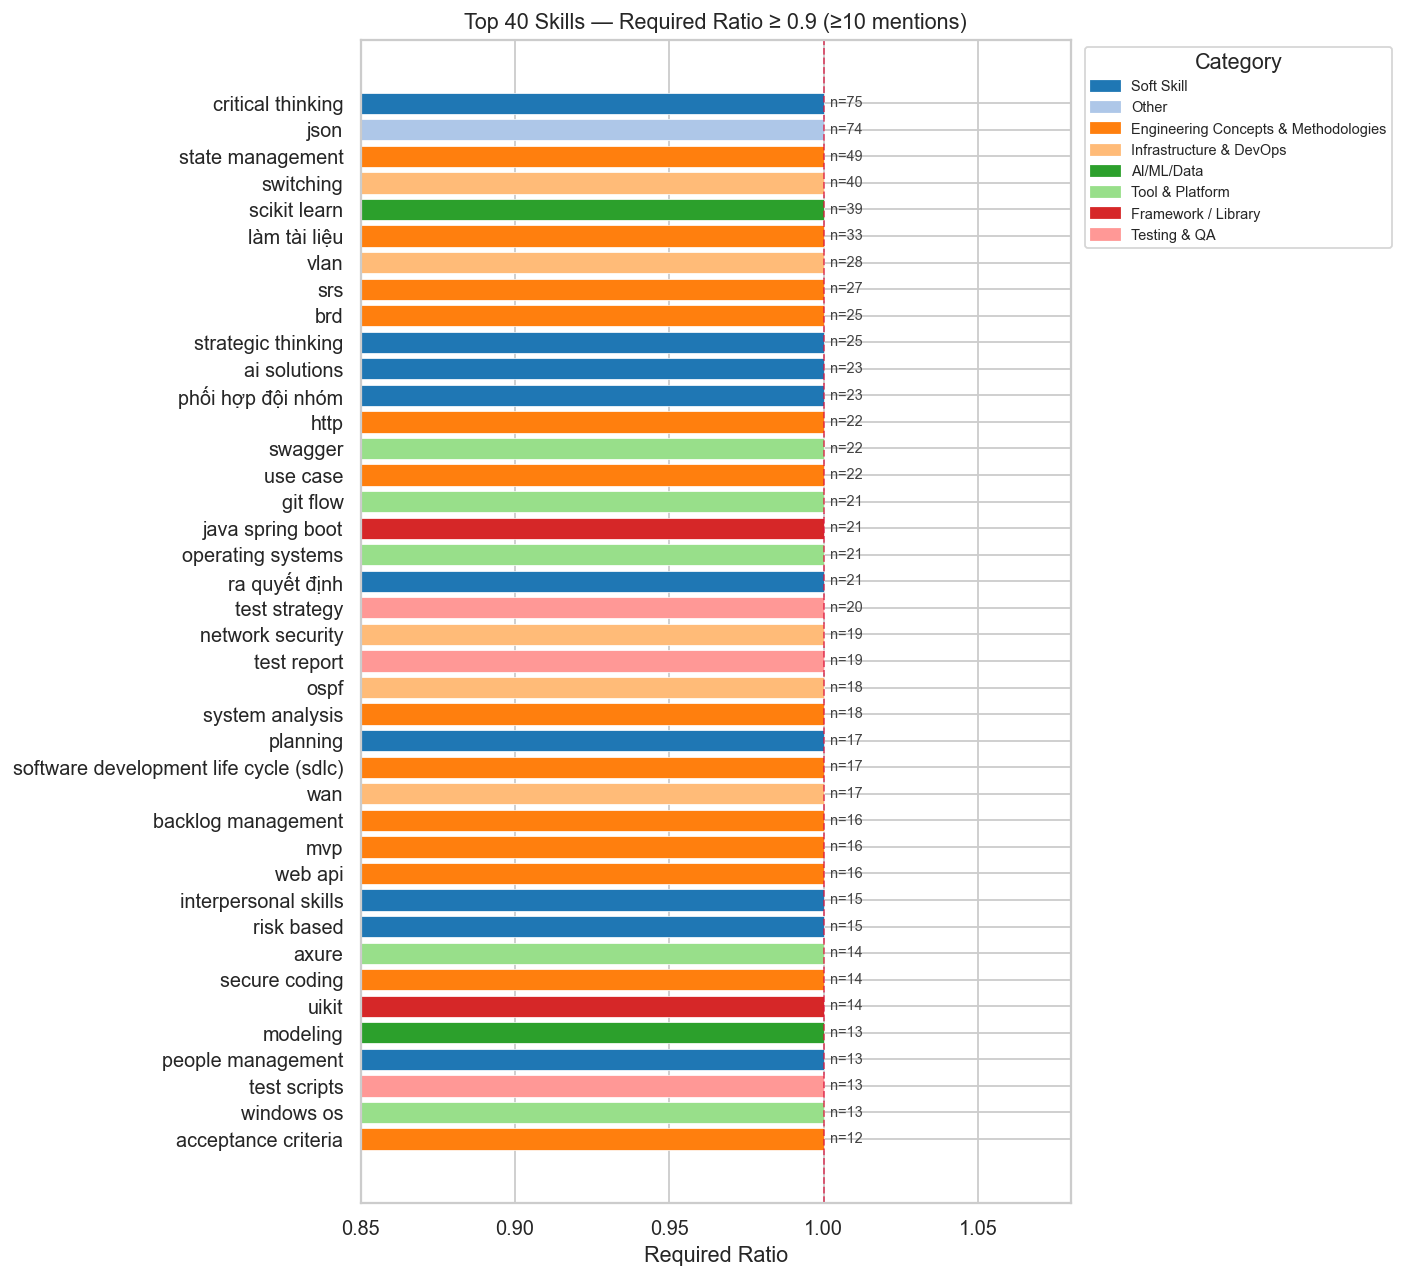

In [5]:
REQUIRED_THRESHOLD = 0.90

always_required = (
    skill_filtered[skill_filtered['required_ratio'] >= REQUIRED_THRESHOLD]
    .sort_values(['required_ratio', 'total'], ascending=[False, False])
    .head(40)
)

# Màu theo category
categories = always_required['category'].unique()
palette = sns.color_palette('tab20', len(categories))
cat_color = dict(zip(categories, palette))
bar_colors = always_required['category'].map(cat_color)

fig, ax = plt.subplots(figsize=(11, 10))
bars = ax.barh(
    always_required['canonical'],
    always_required['required_ratio'],
    color=bar_colors,
    edgecolor='white', linewidth=0.4,
)

# Ghi số mentions ra đầu mỗi bar
for bar, (_, row) in zip(bars, always_required.iterrows()):
    ax.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"n={int(row['total'])}",
        va='center', ha='left', fontsize=8, color='#444'
    )

ax.axvline(1.0, color='crimson', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlim(0.85, 1.08)
ax.set_xlabel('Required Ratio')
ax.set_title(f'Top 40 Skills — Required Ratio ≥ {REQUIRED_THRESHOLD} (≥10 mentions)')
ax.invert_yaxis()

legend_patches = [mpatches.Patch(color=c, label=cat) for cat, c in cat_color.items()]
ax.legend(handles=legend_patches, title='Category', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

## 5. Top skills hầu như luôn preferred (ratio ≤ 0.30)

ValueError: 'facecolor' or 'color' argument must be a valid color or sequence of colors.

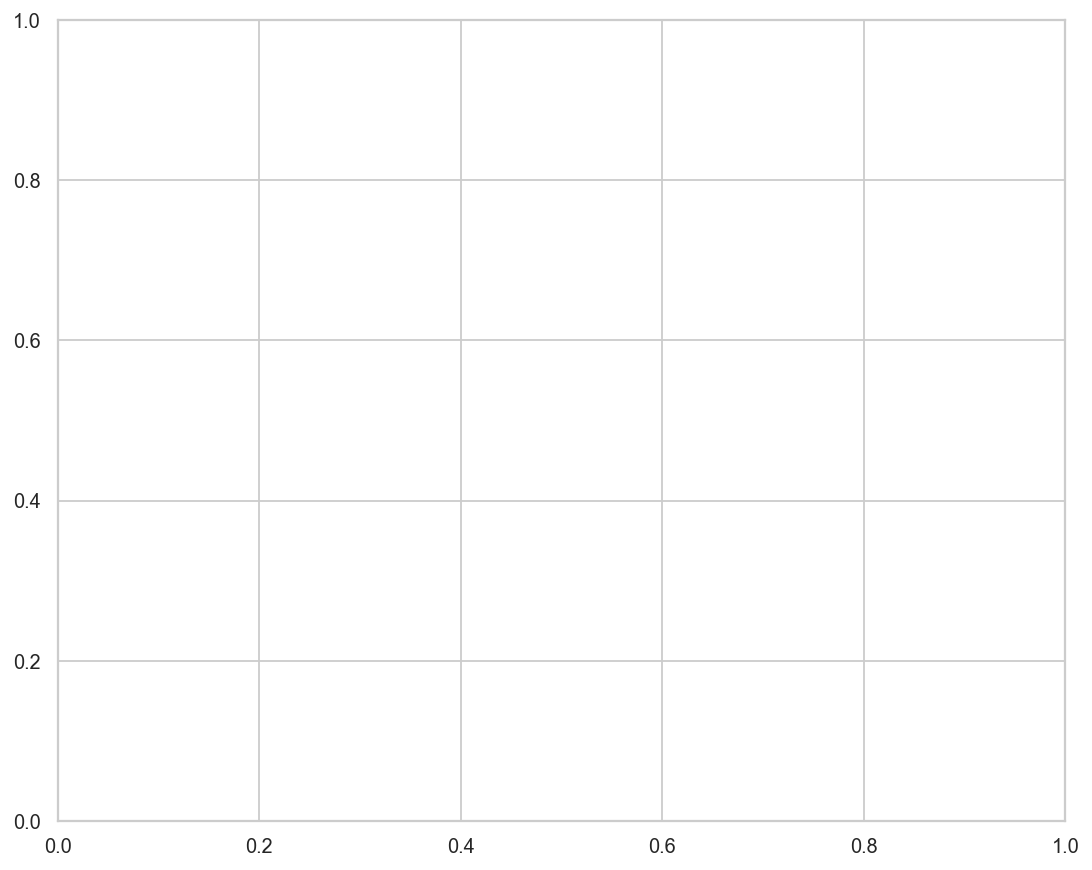

In [6]:
PREFERRED_THRESHOLD = 0.30

always_preferred = (
    skill_filtered[skill_filtered['required_ratio'] <= PREFERRED_THRESHOLD]
    .sort_values(['required_ratio', 'total'], ascending=[True, False])
    .head(30)
)

bar_colors_pref = always_preferred['category'].map(cat_color)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(
    always_preferred['canonical'],
    always_preferred['required_ratio'],
    color=bar_colors_pref,
    edgecolor='white', linewidth=0.4,
)

for bar, (_, row) in zip(bars, always_preferred.iterrows()):
    ax.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"n={int(row['total'])}",
        va='center', ha='left', fontsize=8, color='#444'
    )

ax.axvline(0.0, color='crimson', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlim(-0.02, 0.45)
ax.set_xlabel('Required Ratio  (thấp = thường là preferred)')
ax.set_title(f'Top 30 Skills — Required Ratio ≤ {PREFERRED_THRESHOLD} (≥10 mentions)')
ax.invert_yaxis()

legend_patches2 = [mpatches.Patch(color=c, label=cat) for cat, c in cat_color.items()
                   if cat in always_preferred['category'].values]
ax.legend(handles=legend_patches2, title='Category', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

## 6. Required ratio by Category — boxplot

C:\Users\tncn2\AppData\Local\Temp\ipykernel_20260\1150244557.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


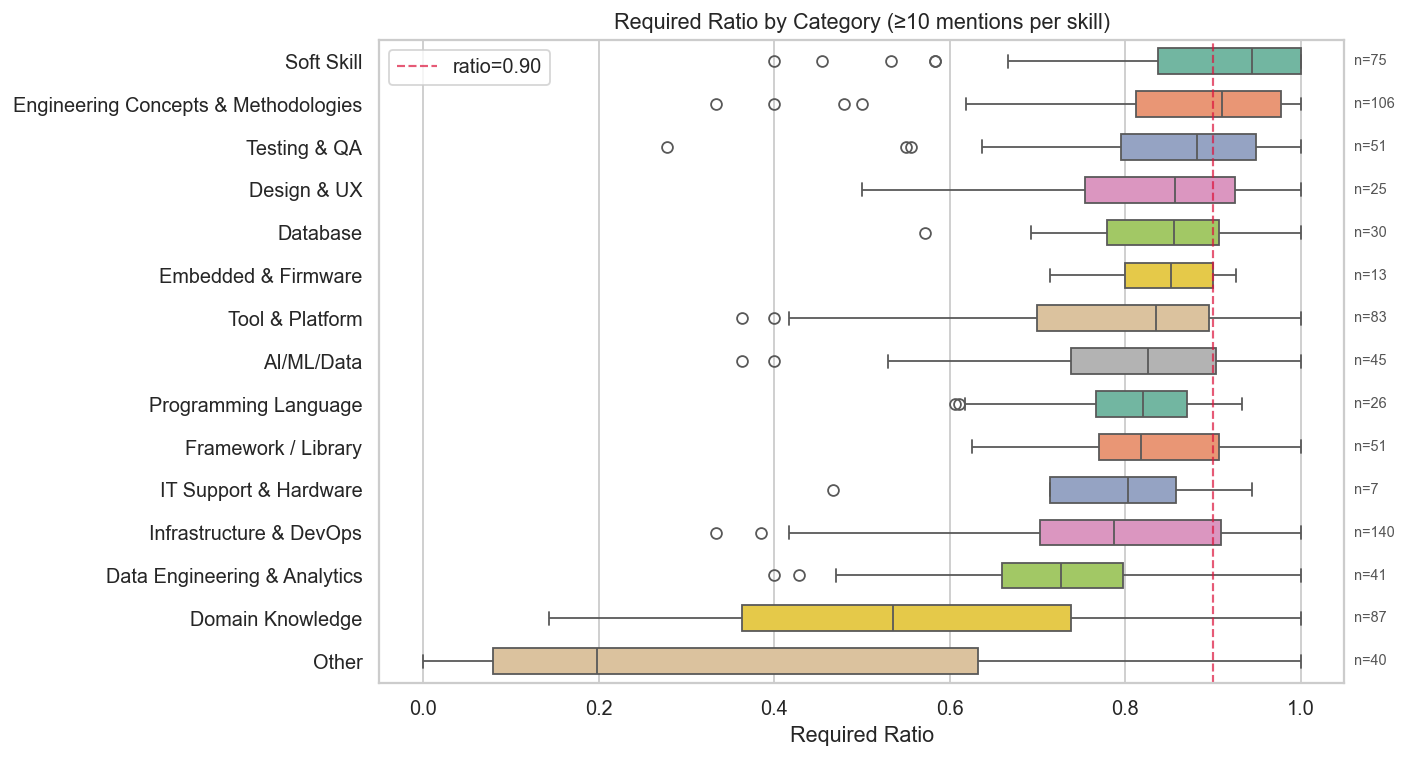

In [7]:
# Median required_ratio per category (để sort)
cat_order = (
    skill_filtered.groupby('category')['required_ratio']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(
    data=skill_filtered,
    x='required_ratio', y='category',
    order=cat_order,
    palette='Set2',
    width=0.6,
    ax=ax,
)

# Annotate n skills per category
cat_counts = skill_filtered['category'].value_counts()
for i, cat in enumerate(cat_order):
    ax.text(1.01, i, f"n={cat_counts.get(cat, 0)}", va='center', fontsize=8, color='#555',
            transform=ax.get_yaxis_transform())

ax.axvline(0.9, color='crimson', linestyle='--', linewidth=1.2, alpha=0.7, label='ratio=0.90')
ax.set_xlabel('Required Ratio')
ax.set_ylabel('')
ax.set_title('Required Ratio by Category (≥10 mentions per skill)')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Scatter: Required ratio vs. Popularity (n_jobs)

> Skills phổ biến AND luôn required → **signal mạnh nhất** cho salary model.

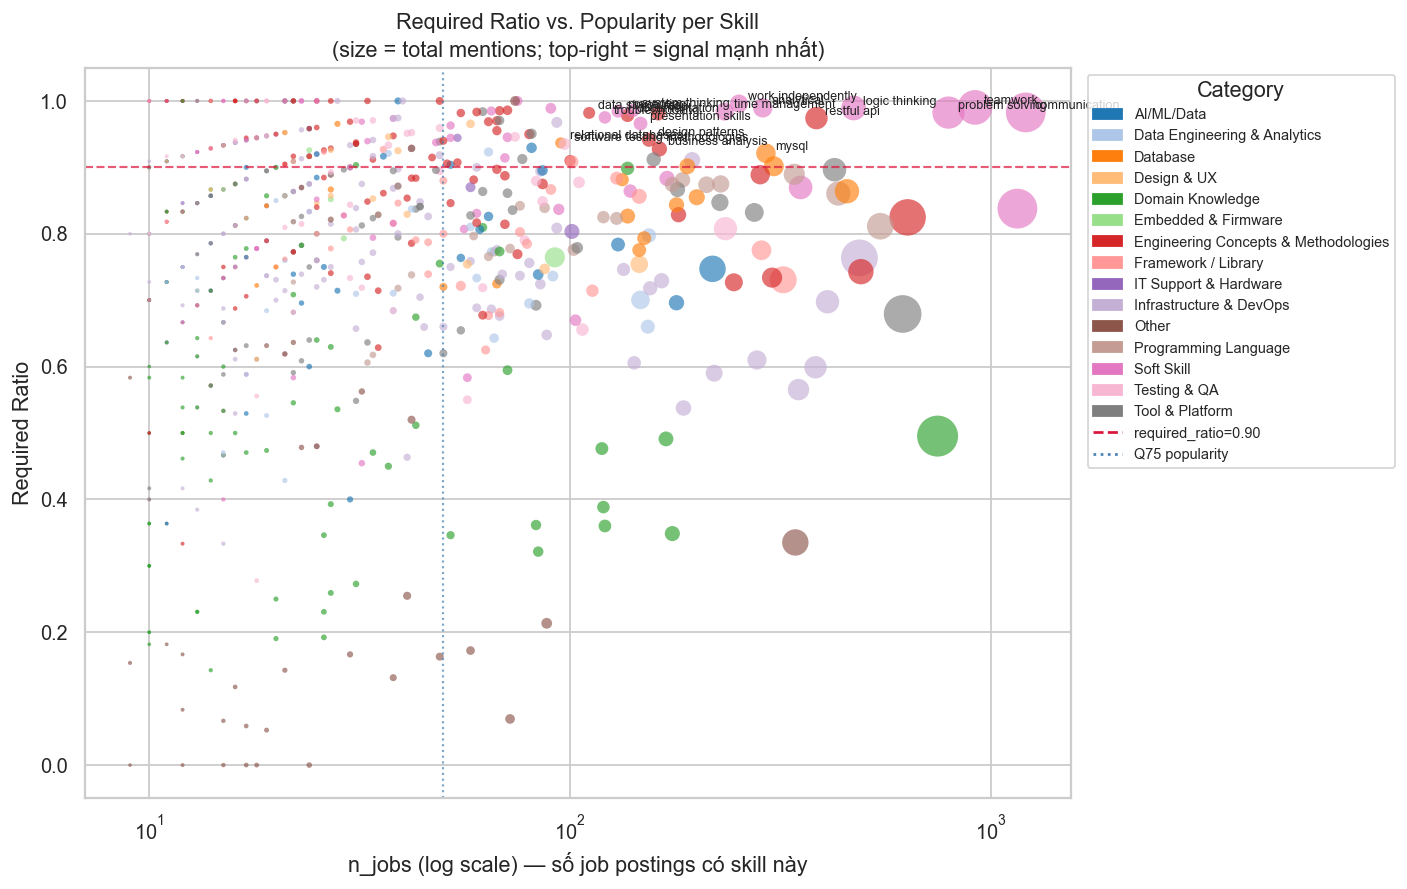

In [8]:
MIN_JOBS = 5   # skill phải xuất hiện trong ít nhất 5 jobs
plot_df = skill_filtered[skill_filtered['n_jobs'] >= MIN_JOBS].copy()

# Tô màu theo category
all_cats = plot_df['category'].unique()
cat_palette = sns.color_palette('tab20', len(all_cats))
cat_col_map = dict(zip(all_cats, cat_palette))
colors = plot_df['category'].map(cat_col_map)

fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(
    plot_df['n_jobs'],
    plot_df['required_ratio'],
    c=colors,
    alpha=0.65,
    s=plot_df['total'] * 0.4,   # size ~ total mentions
    edgecolors='none',
)

# Label top-right quadrant (popular + always required)
top_skills = plot_df[
    (plot_df['required_ratio'] >= 0.92) &
    (plot_df['n_jobs'] >= plot_df['n_jobs'].quantile(0.75))
].nlargest(20, 'n_jobs')

for _, row in top_skills.iterrows():
    ax.annotate(
        row['canonical'],
        xy=(row['n_jobs'], row['required_ratio']),
        xytext=(5, 2), textcoords='offset points',
        fontsize=7, color='#222',
    )

ax.axhline(0.9, color='crimson', linestyle='--', linewidth=1.2, alpha=0.7, label='required_ratio = 0.90')
ax.axvline(plot_df['n_jobs'].quantile(0.75), color='steelblue', linestyle=':', linewidth=1.2,
           alpha=0.7, label='Q75 popularity')

ax.set_xscale('log')
ax.set_xlabel('n_jobs (log scale) — số job postings có skill này')
ax.set_ylabel('Required Ratio')
ax.set_title('Required Ratio vs. Popularity per Skill\n(size = total mentions; top-right = signal mạnh nhất)')

legend_patches3 = [mpatches.Patch(color=c, label=cat) for cat, c in cat_col_map.items()]
ax.legend(handles=legend_patches3 + [
    plt.Line2D([0],[0], color='crimson', linestyle='--', label='required_ratio=0.90'),
    plt.Line2D([0],[0], color='steelblue', linestyle=':', label='Q75 popularity'),
], title='Category', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

## 8. Heatmap: Required ratio by Category × Top Skills

Top 10 skills theo popularity trong mỗi category, tô màu theo required_ratio.

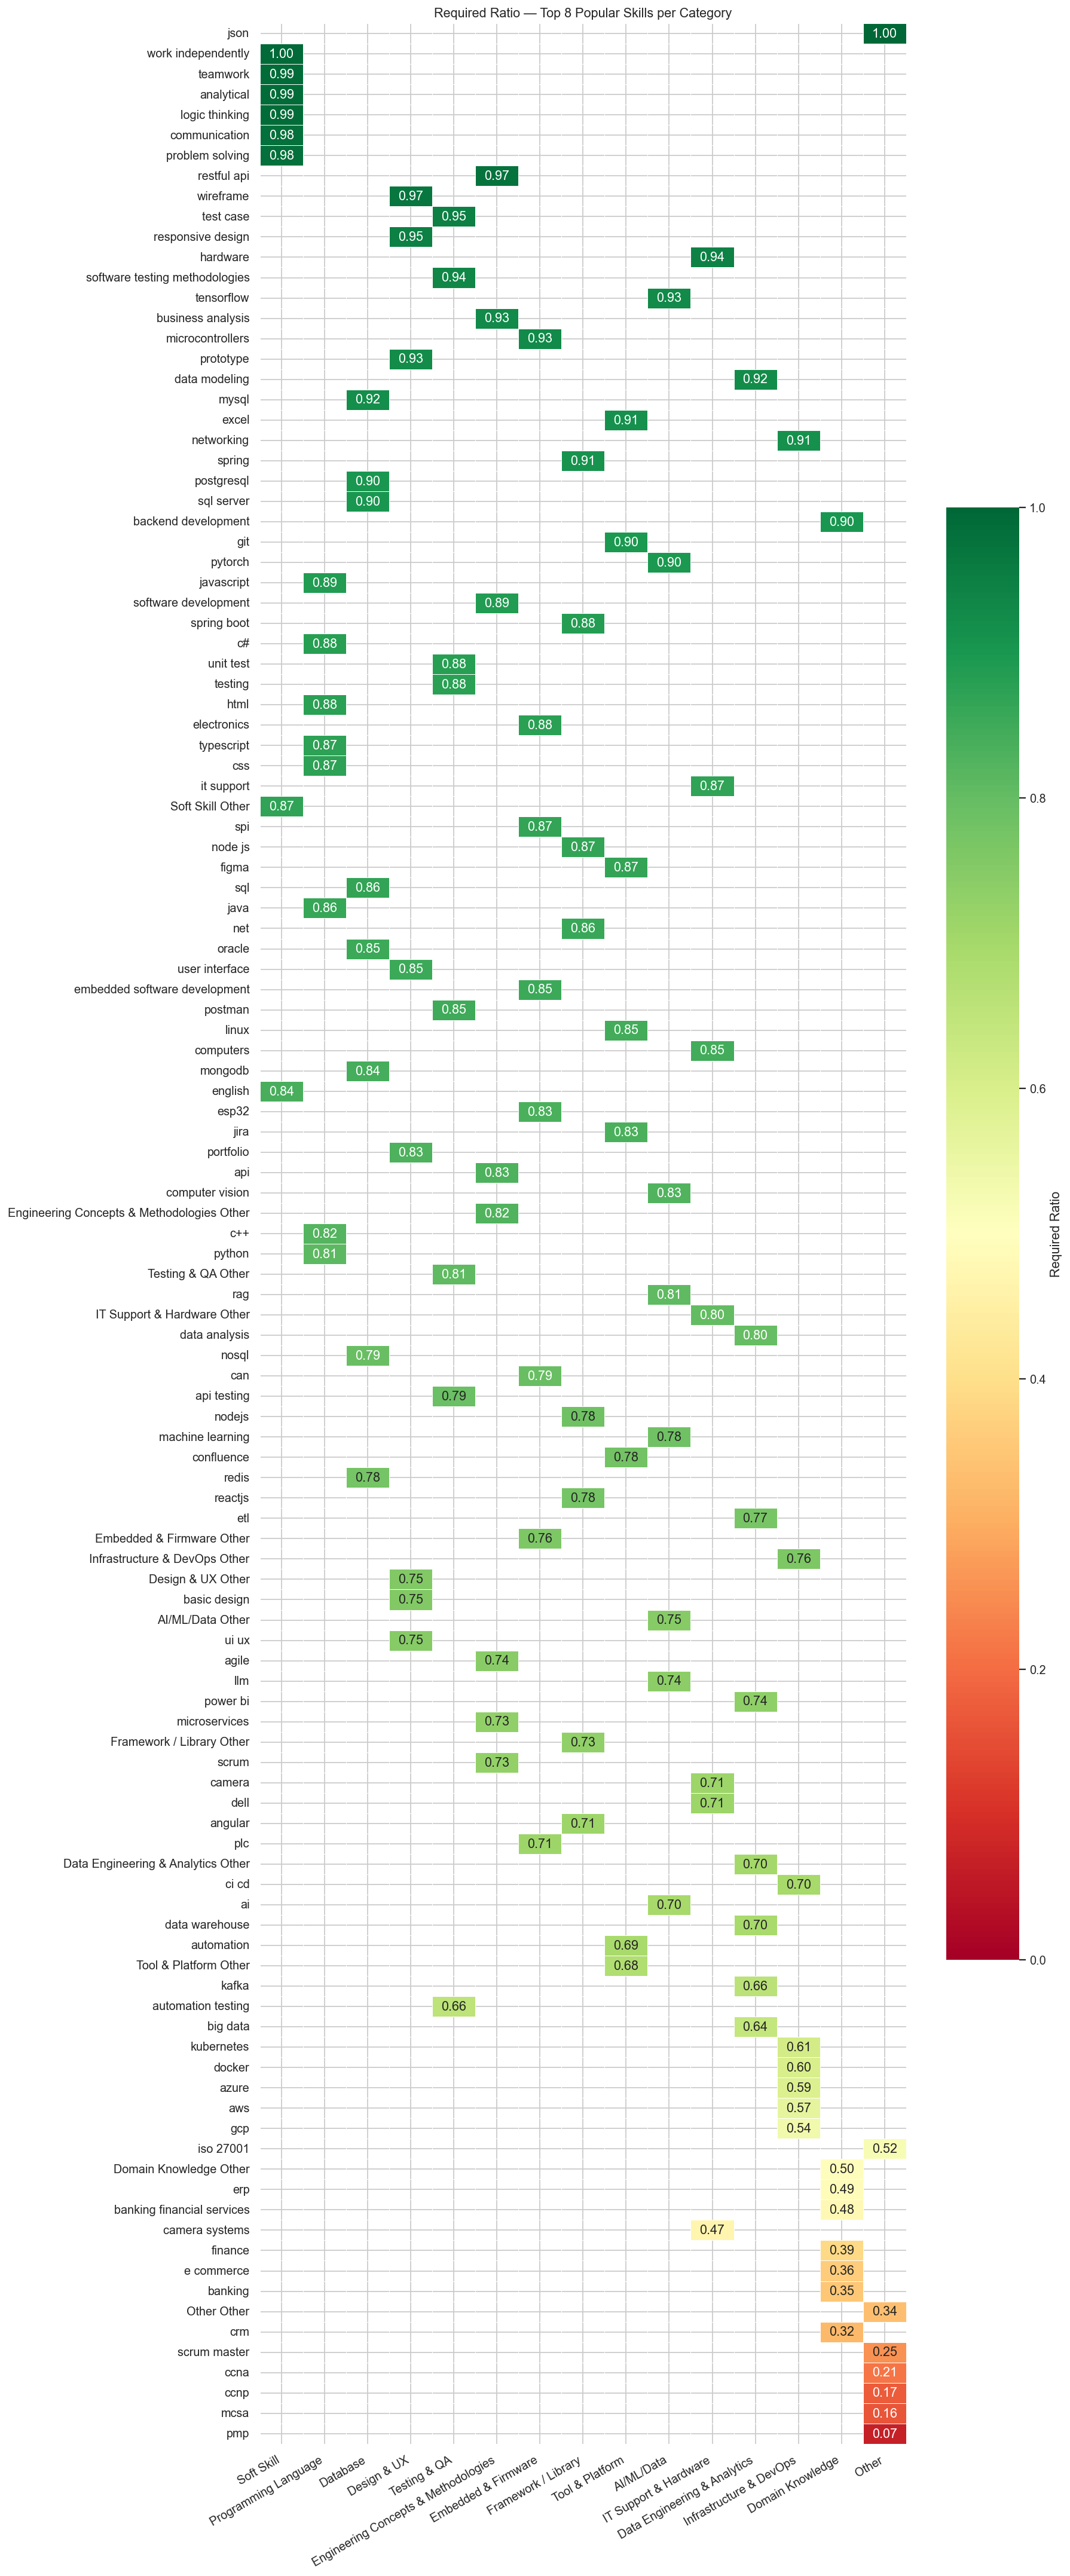

In [9]:
TOP_PER_CAT = 8

top_per_cat = (
    skill_filtered
    .sort_values('n_jobs', ascending=False)
    .groupby('category')
    .head(TOP_PER_CAT)
)

pivot = top_per_cat.pivot_table(
    index='canonical', columns='category',
    values='required_ratio', aggfunc='mean'
)

# Sort categories by mean required_ratio (descending)
cat_mean = pivot.mean(skipna=True).sort_values(ascending=False)
pivot = pivot[cat_mean.index]

# Sort skills by their own required_ratio
skill_order = top_per_cat.sort_values('required_ratio', ascending=False)['canonical'].drop_duplicates()
pivot = pivot.reindex(skill_order)

fig, ax = plt.subplots(figsize=(14, max(8, len(pivot) * 0.28)))
sns.heatmap(
    pivot,
    cmap='RdYlGn',
    vmin=0, vmax=1,
    annot=True, fmt='.2f',
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': 'Required Ratio', 'shrink': 0.6},
    ax=ax,
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title(f'Required Ratio — Top {TOP_PER_CAT} Popular Skills per Category')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 9. Summary table — Strong Signal Skills

Export danh sách skill được coi là **strong required signal** (required_ratio ≥ 0.90, n_jobs ≥ Q75 popularity).

In [10]:
q75_jobs = skill_filtered['n_jobs'].quantile(0.75)

strong_signal = (
    skill_filtered[
        (skill_filtered['required_ratio'] >= 0.90) &
        (skill_filtered['n_jobs'] >= q75_jobs)
    ]
    .sort_values(['n_jobs', 'required_ratio'], ascending=[False, False])
    [['canonical', 'category', 'n_jobs', 'total', 'n_required', 'n_preferred', 'required_ratio']]
    .reset_index(drop=True)
)

print(f"Strong required signal skills: {len(strong_signal)}")
print(f"(required_ratio ≥ 0.90 AND n_jobs ≥ {q75_jobs:.0f})")
print()
strong_signal

Strong required signal skills: 57
(required_ratio ≥ 0.90 AND n_jobs ≥ 50)



,canonical,category,n_jobs,total,n_required,n_preferred,required_ratio
0,communication,Soft Skill,1210,1211,1190,21,0.982659
1,teamwork,Soft Skill,917,923,914,9,0.990249
2,problem solving,Soft Skill,793,798,784,14,0.982456
3,logic thinking,Soft Skill,472,472,467,5,0.989407
4,restful api,Engineering Concepts & Methodologies,385,387,377,10,0.974160
5,postgresql,Database,305,305,275,30,0.901639
6,mysql,Database,292,292,269,23,0.921233
7,analytical,Soft Skill,287,289,286,3,0.989619
8,work independently,Soft Skill,252,252,251,1,0.996032
9,time management,Soft Skill,233,249,245,4,0.983936


In [ ]:
# Optional: lưu để dùng cho feature engineering
# strong_signal.to_csv('../data/processed/strong_required_skills.csv', index=False)
# print('Saved.')